# Physically motivated phase curve models II: reflected light (homogeneously reflective sphere)

[Heng et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021NatAs...5.1001H/abstract) derived ab-initio solutions of reflected light phase curves for homogeneously reflective sphere. These models can be computed from single scattering albedo and scattering asymmetry factor, in addition to the planetary parameters. These models have been included in [`kelp`](https://kelp.readthedocs.io/en/latest/api/kelp.jax.reflected_phase_curve.html#kelp.jax.reflected_phase_curve) package, which we have now implemented in `juliet`. We can use this model to fit the data by providing appropriate priors for this model:

1) `singlescat_p1_intrument`: single scattering albedo of the planet, defined between 0 and 1.
2) `g_p1_instrument`: scattering asymmetry factor, defined in (-1, 1).

Note that both of these parameters are planetary _and_ instrumental parameters, so, it is possible to share them over multiple instruments. In the current notebook, we will use only one instrument, so, we don't need to specify instrument name -- we can just specify `singlescat_p1` and `g_p1`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gd
from kelp.jax import reflected_phase_curve
from tqdm import tqdm
import seaborn as sns
import plotstyles
import juliet
import os

## I have MacBook Pro with M1 chip, so I need following two lines for multiprocessing to work
import multiprocessing
multiprocessing.set_start_method('fork')

print('juliet version:', juliet.__version__)

juliet version: 2.2.9


We will use Kepler data of a hot Jupiter HAT-P-7 b as observed in Quarter 4. Let's first load some orbital parameters from the literature.

In [2]:
# And priros
## We need planetary and stellar parameters for this (all parameters are from Southworth et al. 2011)
per, per_err = 2.2047304, 0.0000024             # Orbital period in days
t0, t0_err = 2454954.357463, 0.000005            # Transit epoch in BJD (Morris et al. 2013)

And the data:

(-8.0, 1.5)

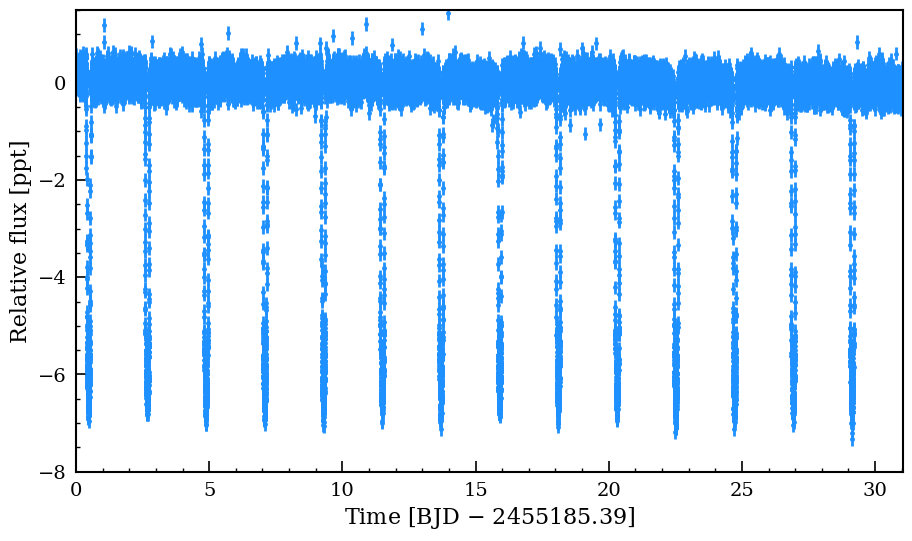

In [3]:
tim4, fl4, fle4 = np.loadtxt(os.getcwd() + '/Data/HATP7_Q4.dat',\
                                usecols=(0,1,2), unpack=True)

# Ploting the data
fig, axs = plt.subplots()
axs.errorbar(tim4-tim4[0], (fl4-1)*1e3, yerr=fle4*1e3, fmt='.', color='dodgerblue')
axs.set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim4[0]))
axs.set_ylabel('Relative flux [ppt]')
axs.set_xlim([0., np.max(tim4-tim4[0])])
axs.set_ylim([-8., 1.5])

Now, we will define the priors. We will provide uninformative priors on most of the planetary parameters exceppt of orbital period and transit time. Since we are also fitting transit and not just phase curves, we will provide priors on limb darkening coefficients. Finally, to activate `kelp` reflected light phase curve for homogeneously reflective sphere, we will provide priors on `singlescat_p1` and `g_p1`.

Also, we will self consistently calculate occultation time from the orbital parameters. To do this, we will _not_ provide priors on `t_secondary_p1`, but will use `light_travel_delay=True` and provide `stellar_radius` in `juliet.fit`.

We will fit additional noise in the data with GP models (SHO kernel).

In [4]:
# Instrument name
instrument = 'Kepler4'

# Creating data dictionaries the way juliet understands
tim, fl, fle = {}, {}, {}
tim[instrument], fl[instrument], fle[instrument] = tim4, fl4, fle4

### Predicting transit and occultation time for our observations
cycle = round((tim4[0] - t0) / per)
tc, tc_err = t0 + cycle*per, np.sqrt(t0_err**2 + (cycle*per_err)**2)
tsec, tsec_err = tc + (per/2), np.sqrt(tc_err**2 + per_err**2)

# Designing priors
## Planetary parameters
par_P = ['P_p1', 't0_p1', 'p_p1', 'b_p1', 'q1_' + instrument, 'q2_' + instrument, 'ecc_p1', 'omega_p1', 'a_p1']
dist_P = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform']
hyper_P = [[per, 3*per_err], [tc, 3*tc_err], [0., 1.], [0., 1.], [0., 1.], [0., 1.], 0., 90., [1., 10.]]
## Occultation depth
par_pc = ['singlescat_p1', 'g_p1']
dist_pc = ['uniform', 'truncatednormal']
hyper_pc = [[0., 1.], [0., 0.1, -1., 1.]]

## Instrumental priors
par_ins = ['mdilution_' + instrument, 'mflux_' + instrument, 'sigma_w_' + instrument]
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1.0, [0., 0.1], [0.1, 10000]]

## GP priors
par_gp = ['GP_S0_' + instrument, 'GP_omega0_' + instrument, 'GP_Q_' + instrument]
dist_gp = ['uniform', 'uniform', 'fixed']
hyper_gp = [[np.exp(-30.), np.exp(-15.)], [2*np.pi/10, 2*np.pi/0.1], 1/np.sqrt(2)]

# Total priors
par_tot = par_P + par_pc + par_ins + par_gp
dist_tot = dist_P + dist_pc + dist_ins + dist_gp
hyper_tot = hyper_P + hyper_pc + hyper_ins + hyper_gp

priors = juliet.utils.generate_priors(params=par_tot, dists=dist_tot, hyperps=hyper_tot)

And, `juliet` fitting:

**Note that this fitting can take several hours!!**

Since the fitting can take several hours, we may want to interrupt the sampler and resume after a while. This is now possible to do in `juliet` with `dynesty` samplers (both `dynesty` and `dynamic_dynesty`). We can now save the states of samplers at a certain fixed intervals, which can be used to resume the sampler later. We simply need to set `dynesty_save_states=True` and provide a time interval over which we want to save state of the sampler (`checkpoint_every` keyword) in `juliet.fit`. Please note that `checkpoint_every` keyword accept time interval in seconds.

In [5]:
# Output folder
pout = os.getcwd() + '/Analysis/Kelp_homo_refl'

# Juliet fitting
data = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle, GP_regressors_lc=tim, out_folder=pout)
res = data.fit(sampler='dynamic_dynesty', nthreads=8, light_travel_delay=True, stellar_radius=1.955,\
               dynesty_save_states=True, checkpoint_every=5*60)#, dynesty_resume=True)

Detected dynamic_dynesty sampler output files --- extracting from /Users/japa6985/Documents/Codes/juliet-examples/Analysis/Kelp_homo_refl/_dynesty_DNS_posteriors.pkl


Alright! We now want to plot the results. First, we need to calculate all models to generate detrended models.

In [6]:
# --------------------------------------------
#    Some planetary models
# --------------------------------------------
## Mflux and sigma_w (white noise)
mflx = res.posteriors['posterior_samples']['mflux_' + instrument]
sigw = np.nanmedian(res.posteriors['posterior_samples']['sigma_w_' + instrument] * 1e-6)
P_post = np.nanmedian(res.posteriors['posterior_samples']['P_p1'])
t0_post = np.nanmedian(res.posteriors['posterior_samples']['t0_p1'])

# --------------------------------------------
#    Extracting all models
# --------------------------------------------
# Creating all models
model = res.lc.evaluate(instrument, nsamples=5000, return_err=True, return_components=True, return_samples=True)
## Saving all models
all_models = res.lc.model[instrument]

# --------------------------------------------
#    Full fitted models
# --------------------------------------------
# Full fitted model:
full_median_model = model[1]
## Sample random full model (to show uncertainties)
sample_models = model[0]
idx_nsamps = np.random.choice( np.arange(sample_models.shape[0]), size=100, replace=False)
random_models = sample_models[idx_nsamps, :]

# --------------------------------------------
#    Detrended data
# --------------------------------------------
## GP model
gp_median_model = all_models['GP']
## F1 and F2 factors (F2=0 for this case since mdilution is fixed to 1)
## See, juliet paper to find their meanings
F1 = np.nanmedian( 1 / ( 1 + mflx ) )
F2 = 0.

# Detrended data and errors
detrended_data = ( fl4 - gp_median_model ) / F1 
detrended_errors = np.sqrt( fle4**2 + sigw**2 )
# Orbital phases (for phase curve)
phases = juliet.utils.get_phases(t=tim4, P=P_post, t0=t0_post, phmin=0.8)

# --------------------------------------------
#    Detrended models
# --------------------------------------------
# Detrended model (we only want to see changes due to planetary parameters so we will fix other params)
post_samps_new = res.posteriors['posterior_samples'].copy()
for i in post_samps_new.keys():
    if ( i[0:5] == 'mflux' ) or ( i[0:9] == 'mdilution' ) or ( i[0:5] == 'theta' ) or ( i[0:2] == 'GP' ):
        post_samps_new[i] = np.zeros(len(post_samps_new[i]))

planet_only_models = res.lc.evaluate(instrument, nsamples=5000, return_err=True, parameter_values=post_samps_new,\
                                     return_components=True, return_samples=True, evaluate_transit=True)

# Sorting indices according to orbital phases
idx_phs = np.argsort(phases)

# Detrended median model
detrended_median_model = planet_only_models[1][idx_phs]
## Corresponding phases
phases_of_detrended_model = phases[idx_phs]
## Random models to show uncertainties
sample_pl_models = planet_only_models[0][:, idx_phs]
idx_nsamps_pl = np.random.choice( np.arange(sample_pl_models.shape[0]), size=100, replace=False)
random_pl_models = sample_pl_models[idx_nsamps_pl, :]

# --------------------------------------------
#    Binned data for visuals
# --------------------------------------------
# Residuals and binned data
resids = fl4 - full_median_model

# Binned data (for phase curves)
bin_phs, bin_det, bin_deterr = juliet.utils.bin_data(x=phases[idx_phs], y=detrended_data[idx_phs], n_bin=1000, yerr=detrended_errors[idx_phs])
_, bin_res, bin_reserr = juliet.utils.bin_data(x=phases[idx_phs], y=resids[idx_phs], n_bin=1000, yerr=detrended_errors[idx_phs])

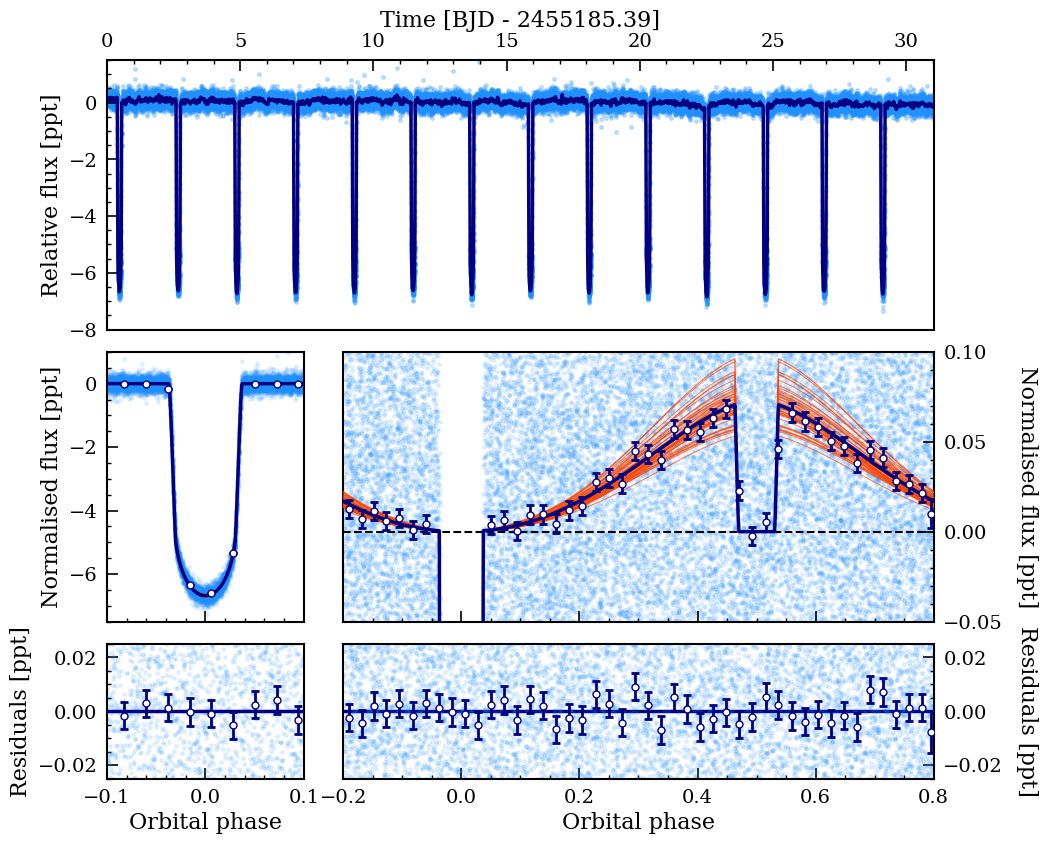

In [7]:
fig = plt.figure(figsize=(16/1.5, 14/1.5))
gs = gd.GridSpec(3, 2, height_ratios=[6,6,3], width_ratios=[1,3], hspace=0.1, wspace=0.1)

ax0 = plt.subplot(gs[0,:])
ax0.errorbar(tim4-tim4[0], (fl4-1.)*1e3, fmt='.', alpha=0.25, c='dodgerblue', zorder=1)
ax0.plot(tim4-tim4[0], (full_median_model-1.)*1e3, c='navy', lw=2.5, zorder=50)
for rand in range(100):
    ax0.plot(tim4-tim4[0], (random_models[rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)

ax0.set_ylabel('Relative flux [ppt]')
ax0.set_xlabel('Time [BJD - {:.2f}]'.format(tim4[0]))
ax0.xaxis.tick_top()
ax0.xaxis.set_label_position('top')
ax0.set_xlim([0., np.max(tim4-tim4[0])])
ax0.set_ylim([-8., 1.5])
#ax0.xaxis.set_major_formatter(plt.NullFormatter())

# Transit
xlim1, xlim2 = -0.1, 0.1
## -- Upper panel
ax1 = plt.subplot(gs[1,0])
ax1.errorbar(phases_of_detrended_model, (detrended_data[idx_phs]-1.)*1e3, fmt='.', alpha=0.1, c='dodgerblue', zorder=1)
ax1.errorbar(bin_phs, (bin_det-1.)*1e3, yerr=bin_deterr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax1.plot(phases_of_detrended_model, (detrended_median_model-1.)*1e3, color='navy', lw=2.5, zorder=50)
for i in range(50):
    ax1.plot(phases_of_detrended_model, (random_pl_models[i,:]-1.)*1e3, color='orangered', alpha=0.5, lw=0.7, zorder=10)

ax1.set_ylabel('Normalised flux [ppt]')
ax1.set_xlim([xlim1, xlim2])
ax1.set_ylim([-7.5, 1.])
ax1.xaxis.set_major_formatter(plt.NullFormatter())

## -- Bottom panel
ax2 = plt.subplot(gs[2,0])
ax2.errorbar(phases_of_detrended_model, resids[idx_phs]*1e3, fmt='.', alpha=0.1, c='dodgerblue')
ax2.errorbar(bin_phs, bin_res*1e3, yerr=bin_reserr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=20)
ax2.axhline(0.0, lw=2.5, color='navy', zorder=10)

ax2.set_xlabel('Orbital phase')
ax2.set_ylabel('Residuals [ppt]')
ax2.set_xlim([xlim1, xlim2])
ax2.set_ylim([-0.025, 0.025])


# Phase curve
xlim3, xlim4 = -0.2, 0.8

## Upper panel
ax3 = plt.subplot(gs[1,1])
ax3.errorbar(phases_of_detrended_model, (detrended_data[idx_phs]-1.)*1e3, fmt='.', alpha=0.1, c='dodgerblue', zorder=1)
ax3.errorbar(bin_phs, (bin_det-1.)*1e3, yerr=bin_deterr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax3.plot(phases_of_detrended_model, (detrended_median_model-1.)*1e3, c='navy', lw=2.5, zorder=50)
ax3.axhline(0., color='k', ls='--', lw=1.5, zorder=25)
for i in range(50):
    ax3.plot(phases_of_detrended_model, (random_pl_models[i,:]-1.)*1e3, c='orangered', alpha=0.7, lw=0.7, zorder=10)

ax3.set_ylabel('Normalised flux [ppt]', rotation=270, labelpad=25)
ax3.set_xlim([xlim3, xlim4])
ax3.set_ylim([-0.05, 0.1])
ax3.yaxis.tick_right()
ax3.tick_params(labelright=True)
ax3.yaxis.set_label_position('right')
ax3.xaxis.set_major_formatter(plt.NullFormatter())

## Bottom panel
ax4 = plt.subplot(gs[2,1])
ax4.errorbar(phases_of_detrended_model, resids[idx_phs]*1e3, fmt='.', color='dodgerblue', alpha=0.1)
ax4.errorbar(bin_phs, bin_res*1e3, yerr=bin_reserr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax4.axhline(0., lw=2.5, color='navy')

ax4.set_xlabel('Orbital phase')
ax4.set_ylabel('Residuals [ppt]', rotation=270, labelpad=25)
ax4.set_xlim([xlim3, xlim4])
ax4.set_ylim([-0.025, 0.025])
ax4.yaxis.tick_right()
ax4.tick_params(labelright=True, labelfontfamily='serif')
ax4.yaxis.set_label_position('right')

plt.tight_layout()

In the above plot, the light blue data points are the original unbinned data, while the dark blue open circles are the binned data points. The solid blue and orange lines show the median fitted model and the models computed from the randomly selected posteriors, respectively. The dashed black line in the right middle plot is the baseline flux level, which is set according to the flux during the occultation, i.e., at the stellar flux level.

We can now look at the posteriors of the fitted phase curve parameters:

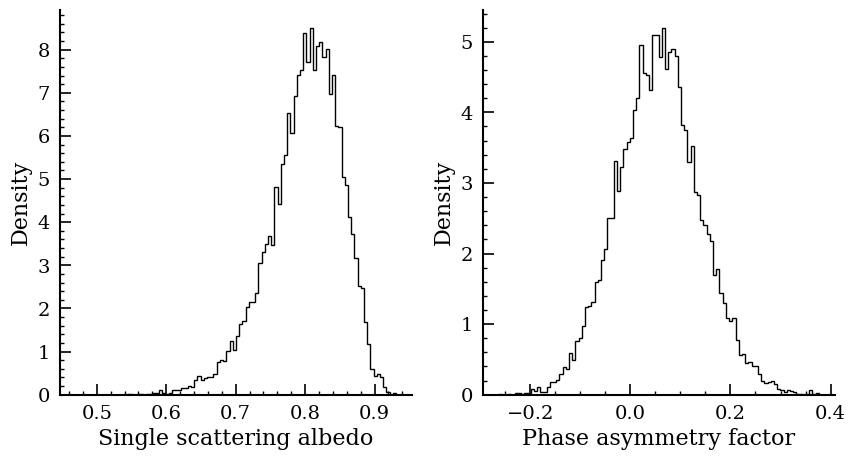

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axs[0].hist(res.posteriors['posterior_samples']['singlescat_p1'], color='k', bins=100, histtype='step', density=True);
axs[0].set_xlabel('Single scattering albedo')
axs[0].set_ylabel('Density')

axs[1].hist(res.posteriors['posterior_samples']['g_p1'], color='k', bins=100, histtype='step', density=True);
axs[1].set_xlabel('Phase asymmetry factor')
axs[1].set_ylabel('Density')

sns.despine()

They look conatrained enough. The value of single scattering albedo seem to be much higher ($\sim 0.8$) than the value published in [Morris et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024A%26A...685A.104M/abstract). This is mostly because [Morris et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024A%26A...685A.104M/abstract) (correctly) also included a thermal emission model, ellipsoidal variation, and doppler booming. Some of the phase amplitude is modelled by these other functions, while in our case, the reflected light model tries to fit everything, resulting in a large single scattering albedo. For our purposes, it is fine to use only reflected light model, however, please note that, we can at add more phase curve models (see, `ca8_lambert.ipynb` notebook).

We can use these phase curve parameters to compute the geometric albedo and integral phase function:

In [9]:
# Dummy phase range
phs = np.linspace(0., 1., 10000)
phs = np.sort(phs[1:-1:])

a_g, q = np.zeros(len(res.posteriors['posterior_samples']['g_p1'])), np.zeros(len(res.posteriors['posterior_samples']['g_p1']))
aRp = res.posteriors['posterior_samples']['a_p1'] / res.posteriors['posterior_samples']['p_p1']

for i in tqdm(range(len(a_g))):
    _, a_g[i], q[i] = reflected_phase_curve(phases=phs, omega=res.posteriors['posterior_samples']['singlescat_p1'][i],\
                                            g=res.posteriors['posterior_samples']['g_p1'][i], a_rp=aRp[i])

# Computing quantiles
## Geometric albedo
qua_ag = juliet.utils.get_quantiles(a_g)
ag_med, ag_up, ag_lo = qua_ag[0], qua_ag[1] - qua_ag[0], qua_ag[0] - qua_ag[2]
## Integral phase function
qua_q = juliet.utils.get_quantiles(q)
q_med, q_up, q_lo = qua_q[0], qua_q[1] - qua_q[0], qua_q[0] - qua_q[2]

print('Geometric albedo: {:.2f} (+{:.2f}) (-{:.2f})'.format(ag_med, ag_up, ag_lo))
print('Integral phase function: {:.2f} (+{:.2f}) (-{:.2f})'.format(q_med, q_up, q_lo))

100%|██████████| 43883/43883 [02:06<00:00, 345.97it/s]

Geometric albedo: 0.21 (+0.03) (-0.03)
Integral phase function: 1.62 (+0.07) (-0.10)


The phase curve modelling is slow for `kelp` phase curves. We can speed up things by not evaluating phase curve model for each time/phase point. We can instead compute the phase curve model on a fixed grid of phases, and then interpolate on the grid to find model for our data points. This can be done by assigning number of fixed grid points of phases with `kelp_refl_interpolation_knots` keyword in `juliet.fit`. Please note that the keyword is the same for kelp reflected light curve phase curve for homogeneously and inhomogeneously reflective sphere.

In [10]:
# Output folder
pout = os.getcwd() + '/Analysis/Kelp_homo_refl_inter'

# Juliet fitting
data_inter = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle, GP_regressors_lc=tim, out_folder=pout)
res_inter = data_inter.fit(sampler='dynamic_dynesty', nthreads=8, light_travel_delay=True, stellar_radius=1.955,\
                           kelp_refl_interpolation_knots=150, dynesty_save_states=True, checkpoint_every=5*60)

Detected dynamic_dynesty sampler output files --- extracting from /Users/japa6985/Documents/Codes/juliet-examples/Analysis/Kelp_homo_refl_inter/_dynesty_DNS_posteriors.pkl


We should check, however, how this affects the posteriors of phase curve parameters:

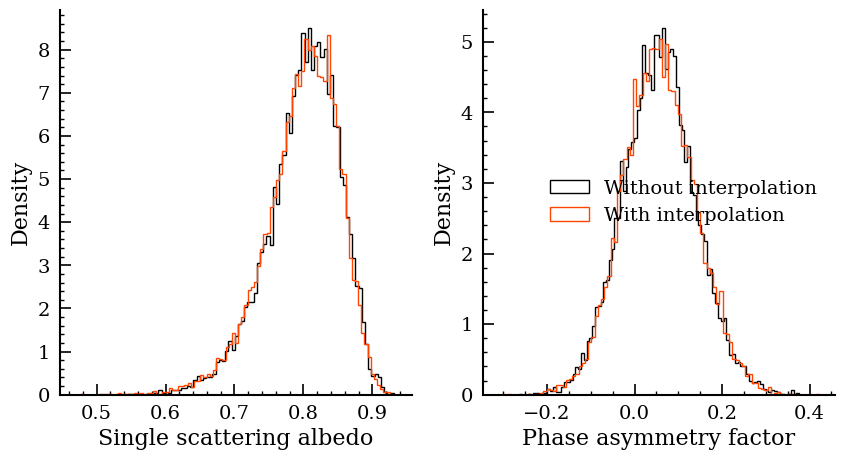

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axs[0].hist(res.posteriors['posterior_samples']['singlescat_p1'], color='k', bins=100, histtype='step', density=True);
axs[0].hist(res_inter.posteriors['posterior_samples']['singlescat_p1'], color='orangered', bins=100, histtype='step', density=True);
axs[0].set_xlabel('Single scattering albedo')
axs[0].set_ylabel('Density')

axs[1].hist(res.posteriors['posterior_samples']['g_p1'], color='k', bins=100, histtype='step', density=True, label='Without interpolation');
axs[1].hist(res_inter.posteriors['posterior_samples']['g_p1'], color='orangered', bins=100, histtype='step', density=True, label='With interpolation');
axs[1].set_xlabel('Phase asymmetry factor')
axs[1].set_ylabel('Density')
axs[1].legend()

sns.despine()

Great! So, they are almost similar to each other, meaning that we can use interpolation technique to speed things up without compromising on results.